<a href="https://colab.research.google.com/github/aliawan7november/Encapsulation/blob/main/MVC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Audio Cleanup Application of Fourier Transform  
Student Name: M. Ali Awan
Roll Number:  Sp23/BSCS/149


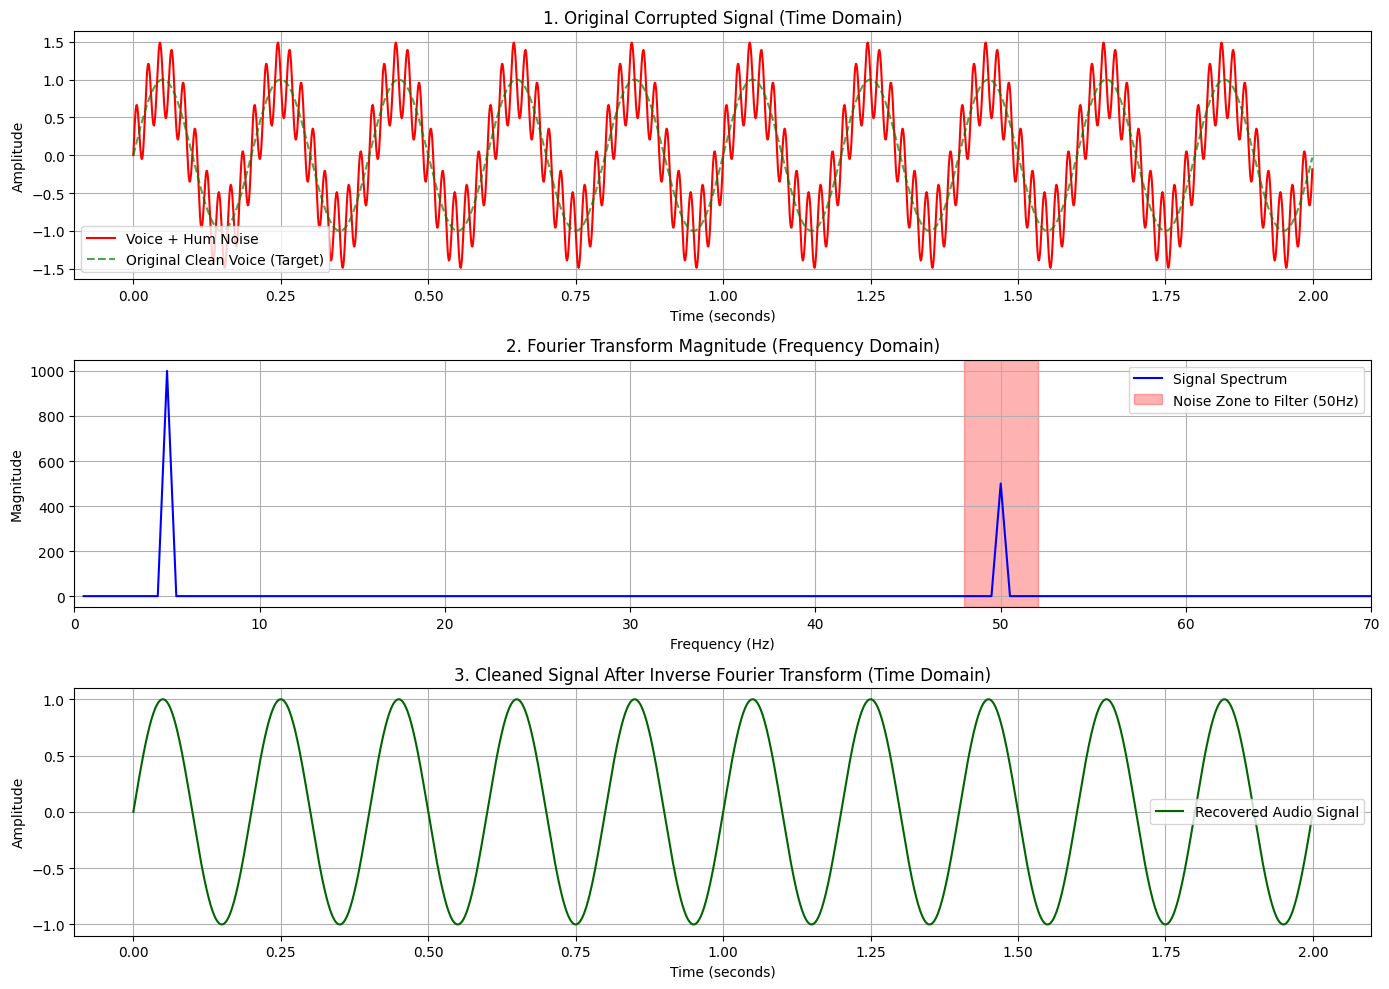

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

name = "M. Ali Awan"
roll_number = "Sp23/BSCS/149"

print("=" * 50)
print("  Audio Cleanup Application of Fourier Transform  ")
print("=" * 50)
print(f"Student Name: {name}")
print(f"Roll Number:  {roll_number}")
print("=" * 50)

sampling_rate = 1000
duration = 2.0
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
dt = t[1] - t[0]

voice_freq = 5
voice_signal = np.sin(2 * np.pi * voice_freq * t)

noise_freq = 50
noise_signal = 0.5 * np.sin(2 * np.pi * noise_freq * t)

noisy_signal = voice_signal + noise_signal

F_omega = np.fft.fft(noisy_signal)
frequencies = np.fft.fftfreq(len(t), d=dt)

F_omega_filtered = F_omega.copy()
noise_mask = (np.abs(frequencies) >= 48) & (np.abs(frequencies) <= 52)
F_omega_filtered[noise_mask] = 0

cleaned_signal = np.fft.ifft(F_omega_filtered).real

plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(t, noisy_signal, color='red', label="Voice + Hum Noise")
plt.plot(t, voice_signal, color='green', linestyle='--', alpha=0.7, label="Original Clean Voice (Target)")
plt.title("1. Original Corrupted Signal (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
positive_frequencies = frequencies > 0
plt.plot(frequencies[positive_frequencies], np.abs(F_omega)[positive_frequencies], color='blue', label="Signal Spectrum")
plt.axvspan(48, 52, color='red', alpha=0.3, label="Noise Zone to Filter (50Hz)")
plt.title("2. Fourier Transform Magnitude (Frequency Domain)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 70)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, cleaned_signal, color='darkgreen', label="Recovered Audio Signal")
plt.title("3. Cleaned Signal After Inverse Fourier Transform (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()